In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [2]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

train.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


In [3]:
train.dtypes

id                              int64
person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
loan_status                     int64
dtype: object

In [4]:
train.shape
train.describe()

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,58645.000000,58645.000000,5.864500e+04,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000
mean,29322.000000,27.550857,6.404617e+04,4.701015,9217.556518,10.677874,0.159238,5.813556,0.142382
std,16929.497605,6.033216,3.793111e+04,3.959784,5563.807384,3.034697,0.091692,4.029196,0.349445
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000
max,58644.000000,123.000000,1.900000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000,1.000000


In [5]:
train.isnull().sum()

id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

In [6]:
train['loan_status'].value_counts(normalize=True)*100

loan_status
0    85.761787
1    14.238213
Name: proportion, dtype: float64

## Распределение целевой переменной

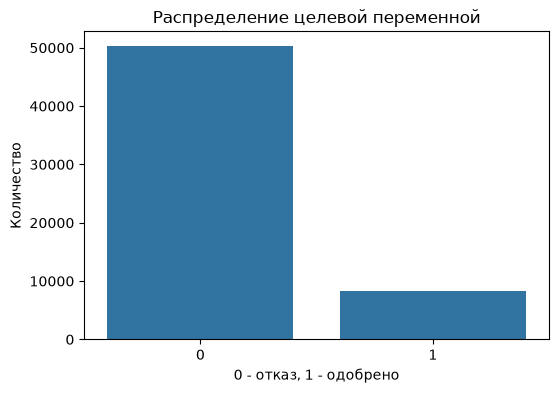

In [7]:
plt.figure(figsize = (6,4))
sns.countplot(x = 'loan_status', data=train)
plt.title('Распределение целевой переменной')
plt.xlabel('0 - отказ, 1 - одобрено')
plt.ylabel('Количество')
plt.show()

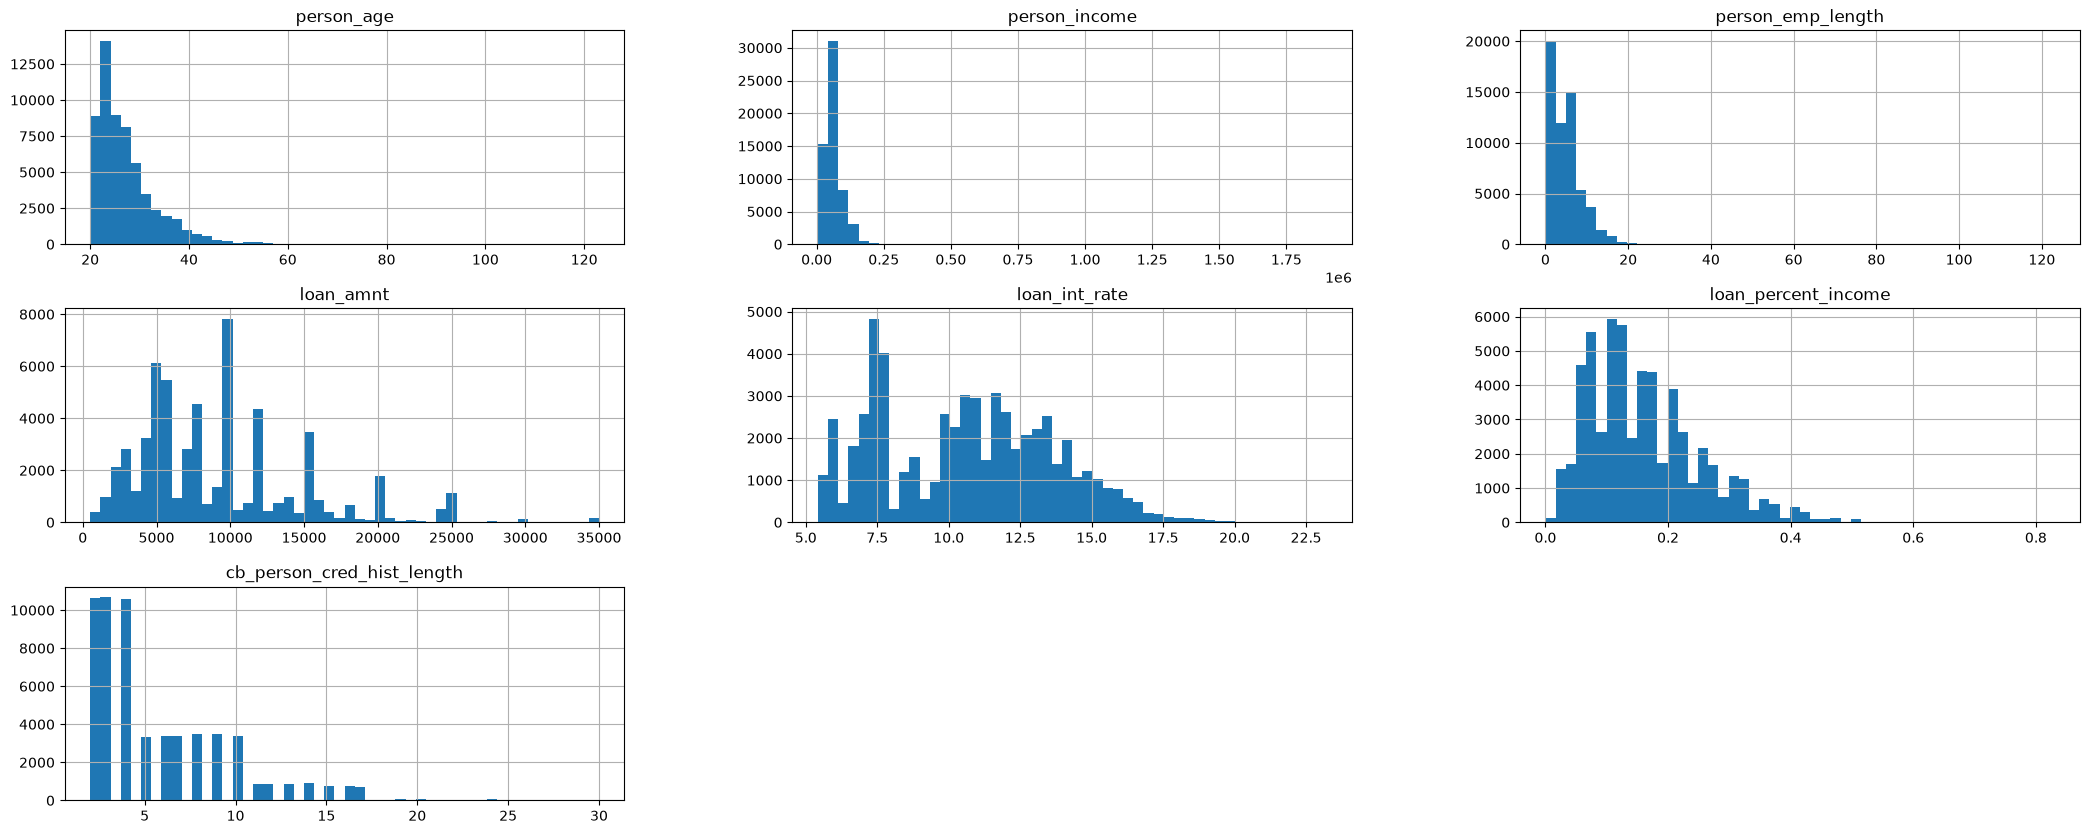

In [8]:
num_cols = ['person_age', 'person_income', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
train[num_cols].hist(bins=50, figsize=(26,10))
plt.show()

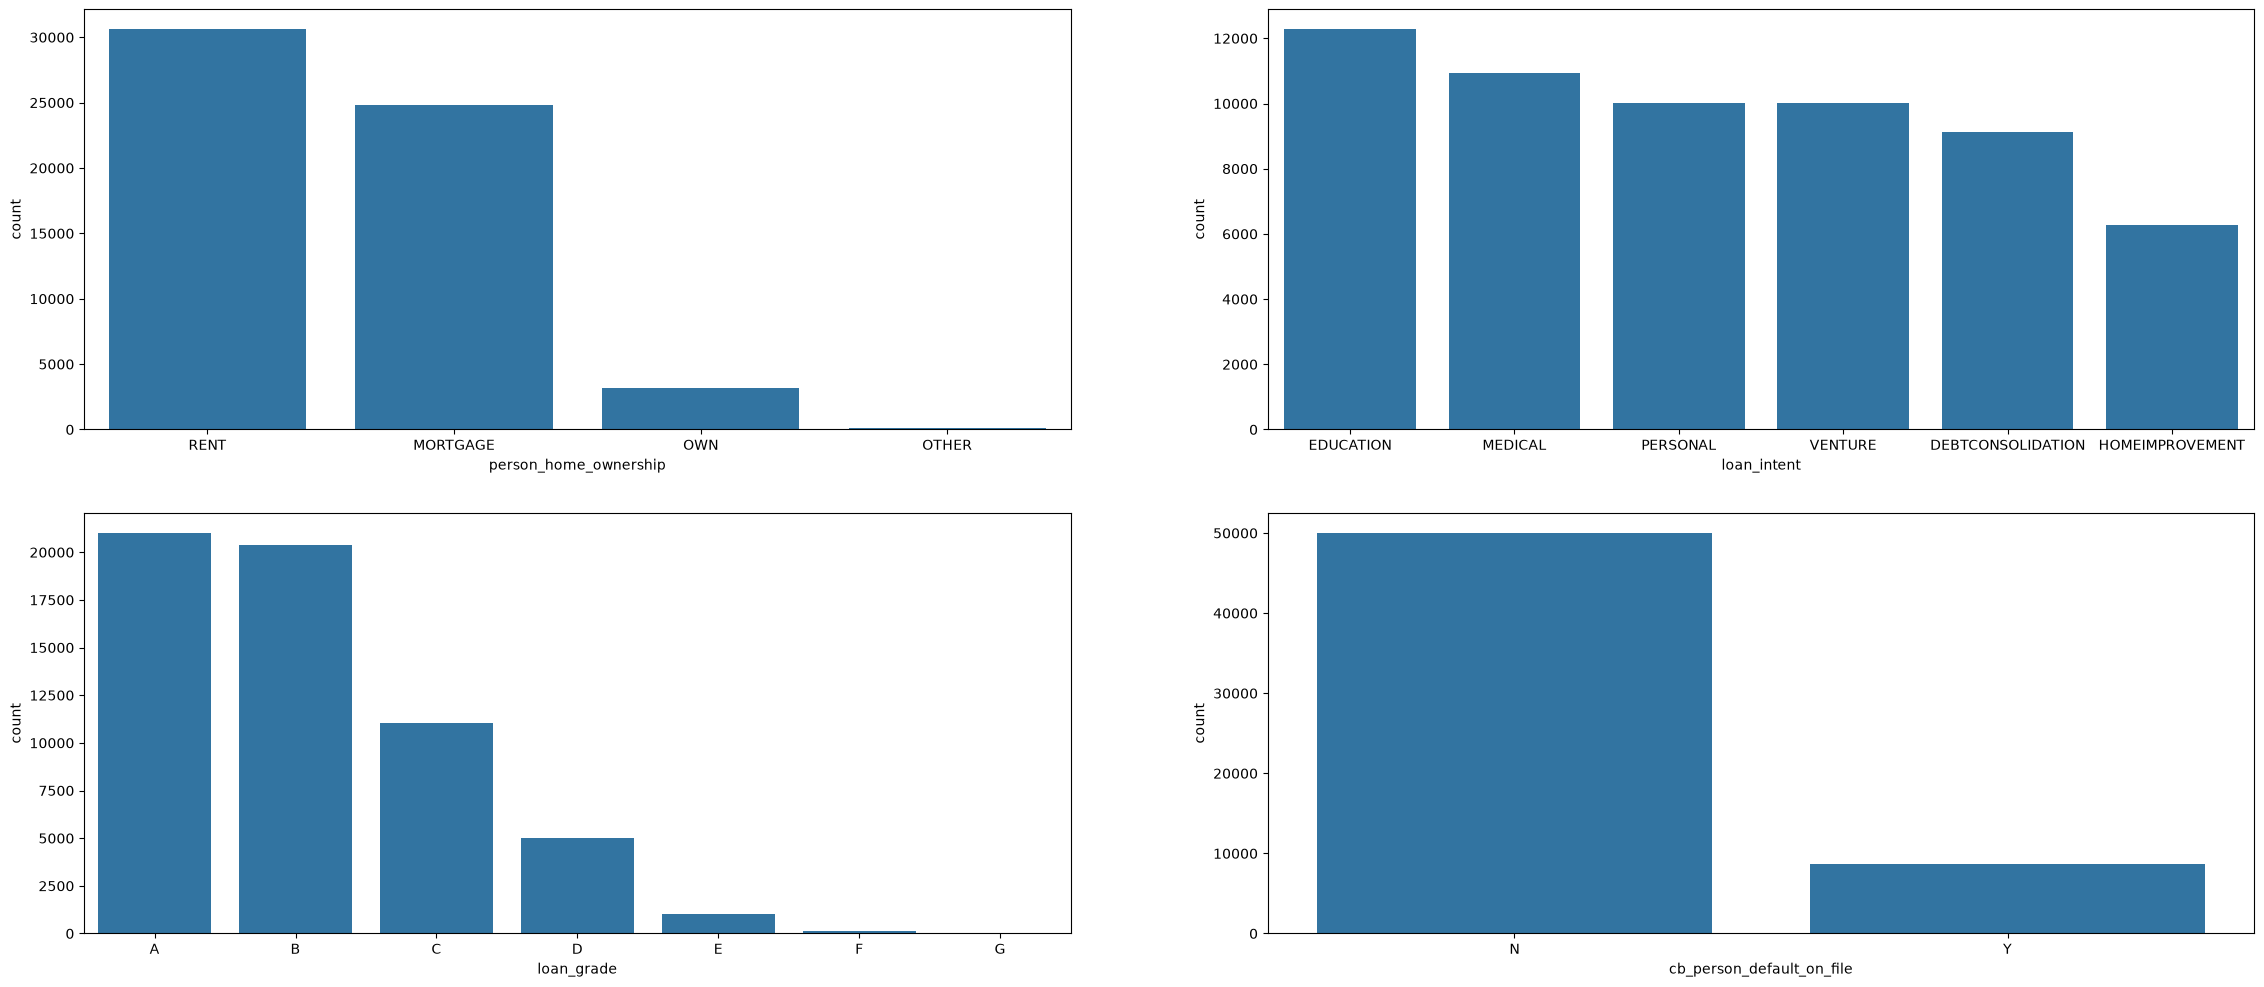

In [9]:
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
fig, axes = plt.subplots(2 , 2, figsize = (28, 12))
for ax, col in zip(axes.flatten(), cat_cols):
    order = train[col].value_counts().index
    sns.countplot(x=col, data = train, order=order, ax=ax)
plt.show()

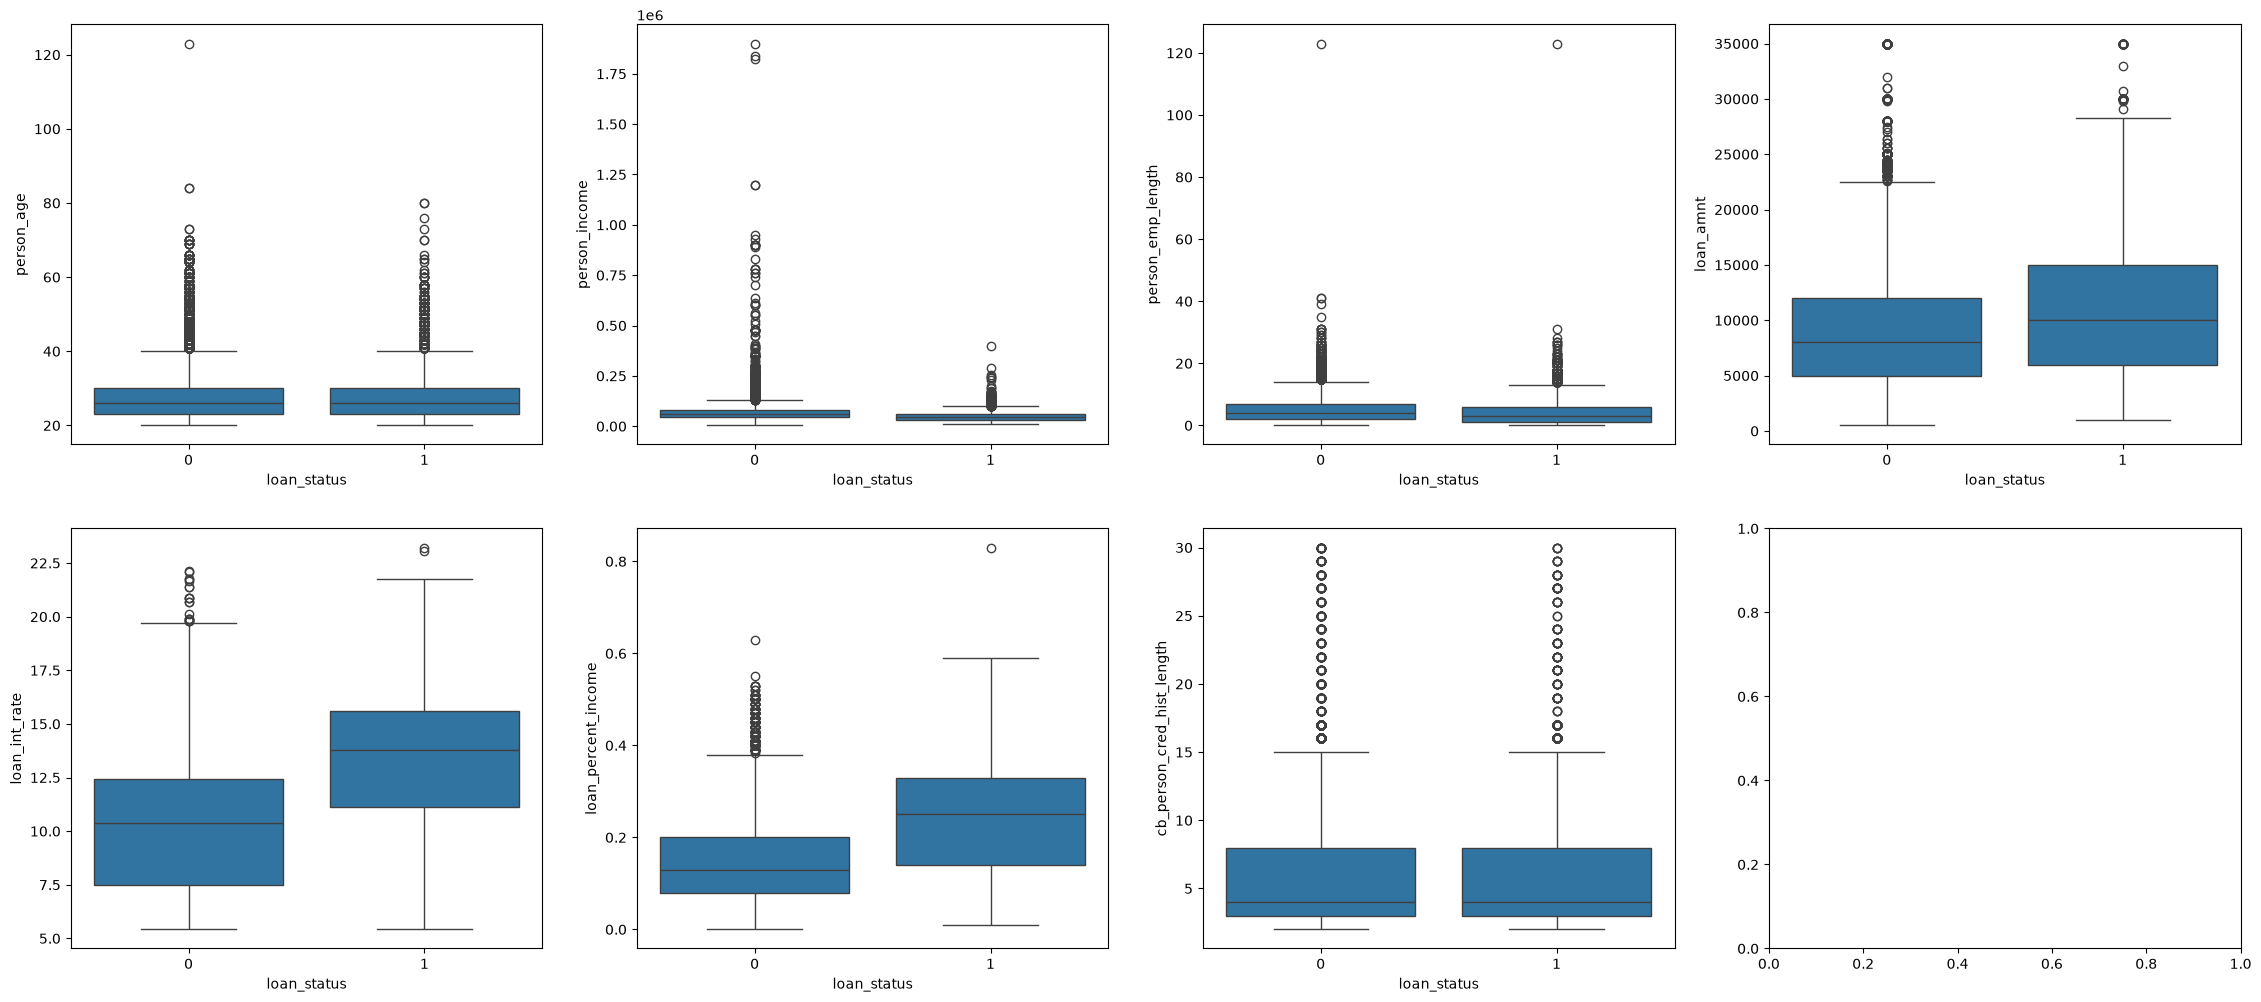

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(28,12))

for ax, cols in zip(axes.flatten(), num_cols):
    sns.boxplot(x='loan_status', data=train, y=cols, ax=ax)

plt.show()

## Кореляционная матрица

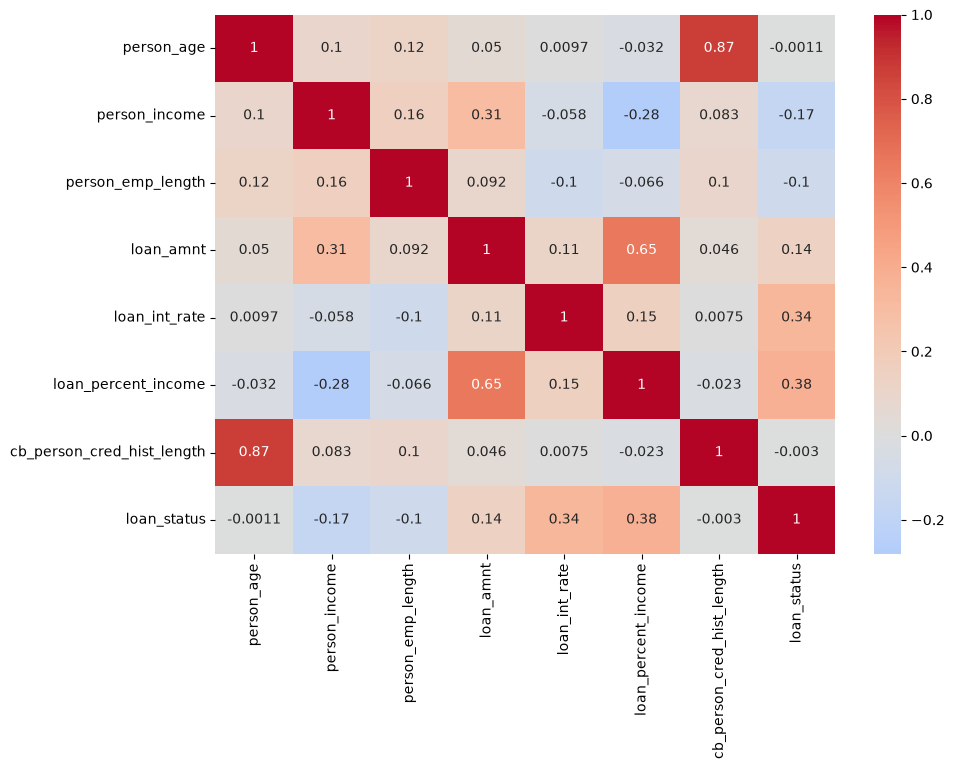

In [11]:
plt.figure(figsize=(10,7))
corr = train[num_cols +  ['loan_status']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.show()